<a href="https://colab.research.google.com/github/CarlosFranciscoM-Urzua/EJERCICIOS_PLN_COLAB/blob/main/UNIGRAMAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Para poder trabajar con unigramas, se necesita wordcloud

In [ ]:
texto = """
El procesamiento de Lenguaje Natural permite que las computadoras
analicen textos escritos por personas. El analisis de textos utiliza
algoritmos astadisticos, aprendizaje automatico y modelos neuronales.
"""

In [ ]:
import re

texto = texto.lower()
texto_limpio = re.sub(r'^[a-záéíóúüñ,.]\s', '', texto)
print(texto_limpio)


el procesamiento de lenguaje natural permite que las computadoras
analicen textos escritos por personas. el analisis de textos utiliza
algoritmos astadisticos, aprendizaje automatico y modelos neuronales.



In [ ]:
tokens = word_tokenize(texto_limpio)
tokens

['el',
 'procesamiento',
 'de',
 'lenguaje',
 'natural',
 'permite',
 'que',
 'las',
 'computadoras',
 'analicen',
 'textos',
 'escritos',
 'por',
 'personas',
 '.',
 'el',
 'analisis',
 'de',
 'textos',
 'utiliza',
 'algoritmos',
 'astadisticos',
 ',',
 'aprendizaje',
 'automatico',
 'y',
 'modelos',
 'neuronales',
 '.']

In [ ]:
stop_words = set(stopwords.words('spanish'))
signos = set([',','.', ' '])

tokens_filtrado = [
    palabra
    for palabra in tokens
    if palabra not in stop_words and palabra not in signos
]

tokens_filtrado

['procesamiento',
 'lenguaje',
 'natural',
 'permite',
 'computadoras',
 'analicen',
 'textos',
 'escritos',
 'personas',
 'analisis',
 'textos',
 'utiliza',
 'algoritmos',
 'astadisticos',
 'aprendizaje',
 'automatico',
 'modelos',
 'neuronales']

In [ ]:
frecuencias = Counter(tokens_filtrado)
frecuencias

Counter({'procesamiento': 1,
         'lenguaje': 1,
         'natural': 1,
         'permite': 1,
         'computadoras': 1,
         'analicen': 1,
         'textos': 2,
         'escritos': 1,
         'personas': 1,
         'analisis': 1,
         'utiliza': 1,
         'algoritmos': 1,
         'astadisticos': 1,
         'aprendizaje': 1,
         'automatico': 1,
         'modelos': 1,
         'neuronales': 1})

In [ ]:
df = pd.DataFrame(
    frecuencias.items(),
    columns=['Palabra', 'Frecuencia']
)

df = df.sort_values(
    by='Frecuencia',
    ascending=False
)

df

,Palabra,Frecuencia
6,textos,2
0,procesamiento,1
1,lenguaje,1
3,permite,1
2,natural,1
4,computadoras,1
5,analicen,1
7,escritos,1
8,personas,1
9,analisis,1


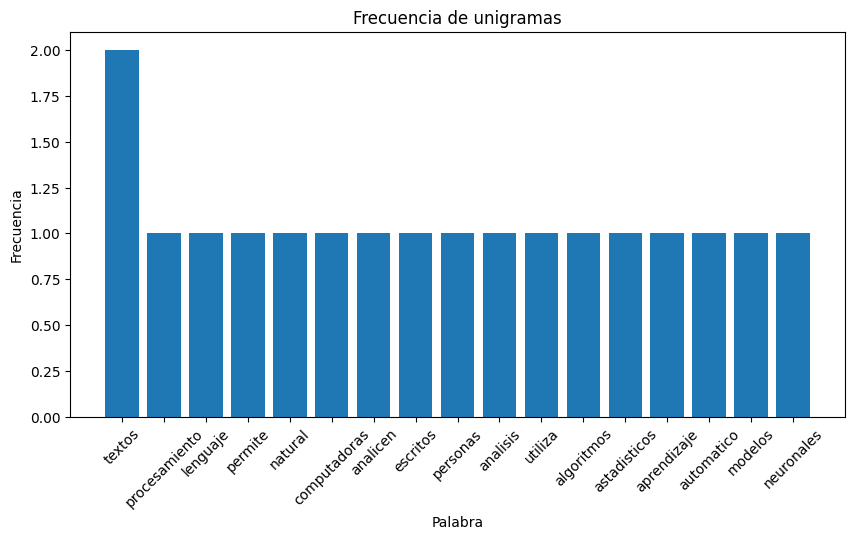

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    df['Palabra'],
    df['Frecuencia']
)

plt.xticks(rotation=45)
plt.title('Frecuencia de unigramas')
plt.xlabel('Palabra')
plt.ylabel('Frecuencia')

plt.show()

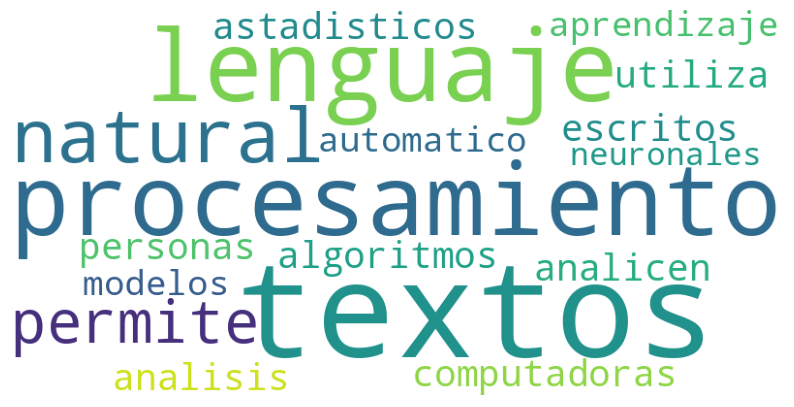

In [ ]:
texto_wc = " ".join(tokens_filtrado)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(texto_wc)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

**¿Cuáles son los 5 unigramas más frecuentes?**

1. textos

2. procesamiento

3. lenguaje

4. natural

5. permite

**¿Qué palabras fueron eliminadas por ser stopwords?**

el, de, que, las, por, el, de, y

In [ ]:
tokens_eliminados = [
    palabra
    for palabra in tokens
    if palabra in stop_words
]

tokens_eliminados

['el', 'de', 'que', 'las', 'por', 'el', 'de', 'y']

**¿Por qué fue importante eliminar stopwords?**

Porque eran palabras que grastan tokens y tiempo de procesamiento sin tener un impacto significativo en el analisis del texto.

**¿Qué información se pierde al trabajar sólo con unigramas?**

Se pierde buena parte del contexto de la información, además de perder el orden con el que aparecen las palabras y el significado real del texto.